# ECON 5140: Applied Econometrics Homework4
---

### Problem 1: Instrumental variables — assumptions and diagnostics

Consider a binary instrument $Z$, binary treatment $D$, and outcome $Y$. Unobserved confounders $U$ may affect both $D$ and $Y$.

**Questions:**

a) State the three main IV assumptions (relevance, independence/exogeneity, exclusion restriction) in words.

b) Which of these can you assess directly from data using a single cross-section? How?

c) What is the **Stock–Yogo style** rule of thumb for a *single* instrument in the first stage? What goes wrong when the instrument is weak?

**Answer 1:**

a) The three IV assumptions are:

1. Relevance: Z has to be correlated with D, i.e. $Cov(Z,D) \neq 0$. The instrument needs to actually affect treatment.

2. Independence: Z is independent of unobserved confounders U, so $Z \perp U$. Basically the instrument should be "as good as random".

3. Exclusion restriction: Z only affects Y through D. There's no direct effect of Z on Y.

b) Only relevance can be tested from data. Run a first-stage regression $D = \pi_0 + \pi_1 Z + error$ and check if $\pi_1$ is significantly different from zero. We look at the F-statistic.

The other two assumptions can't be tested because they involve unobserved stuff. We have to argue for them based on the research design.

c) The Stock-Yogo rule says: if the first-stage F-stat is less than 10, we have a weak instrument problem.

When the instrument is weak:
- The IV estimate gets biased towards OLS
- Standard errors become unreliable
- The estimates are unstable because we're dividing by something close to zero in the Wald formula

### Problem 2: Wald estimator — hand calculation

Observe $n=16$ units

| Unit | $Z$ | $D$ | $Y$ | | Unit | $Z$ | $D$ | $Y$ |
|------|-----|-----|-----|-|------|-----|-----|-----|
| 1 | 1 | 1 | 12 | | 9 | 1 | 0 | 10 |
| 2 | 1 | 0 | 10 | | 10 | 0 | 0 | 6 |
| 3 | 0 | 0 | 6 | | 11 | 1 | 1 | 12 |
| 4 | 1 | 1 | 11 | | 12 | 0 | 1 | 10 |
| 5 | 0 | 1 | 11 | | 13 | 1 | 1 | 12 |
| 6 | 0 | 0 | 5 | | 14 | 0 | 0 | 5 |
| 7 | 1 | 1 | 11 | | 15 | 1 | 0 | 10 |
| 8 | 0 | 0 | 6 | | 16 | 0 | 0 | 7 |

**Answer 2:**

Let me first sort out the data by Z:

Z=1 group (units 1,2,4,7,9,11,13,15): D = {1,0,1,1,0,1,1,0}, Y = {12,10,11,11,10,12,12,10}

Z=0 group (units 3,5,6,8,10,12,14,16): D = {0,1,0,0,0,1,0,0}, Y = {6,11,5,6,6,10,5,7}

a) First stage:

$E[D|Z=1] = 5/8$ (5 treated out of 8)

$E[D|Z=0] = 2/8 = 1/4$ (2 treated out of 8)

First stage = 5/8 - 2/8 = **3/8 = 0.375**

b) Reduced form:

Sum of Y when Z=1: 12+10+11+11+10+12+12+10 = 88, mean = 88/8 = 11

Sum of Y when Z=0: 6+11+5+6+6+10+5+7 = 56, mean = 56/8 = 7

Reduced form = 11 - 7 = **4**

c) Wald estimator = reduced form / first stage = 4 / (3/8) = 4 × 8/3 = **32/3 ≈ 10.67**

d) Naive difference:

D=1 units (1,4,5,7,11,12,13): Y = {12,11,11,11,12,10,12}, sum=79, n=7, mean=79/7≈11.29

D=0 units (2,3,6,8,9,10,14,15,16): Y = {10,6,5,6,10,6,5,10,7}, sum=65, n=9, mean=65/9≈7.22

Naive = 11.29 - 7.22 ≈ **4.07**

e) Under monotonicity, the Wald estimate gives the LATE for compliers - people who take treatment when Z=1 but not when Z=0. So 10.67 is the treatment effect for this group.

f) From the data:

- Always-takers have D=1 even when Z=0, so units with (Z=0, D=1): **units 5 and 12**
- Never-takers have D=0 even when Z=1, so units with (Z=1, D=0): **units 2, 9, and 15**

### Problem 3: Regression discontinuity — bins, thresholds, and causal claims

| Score bin $X$ | Bin midpoint | Average orders $Y$ (bin mean) |
|---------------|--------------|------------------------------|
| $[40, 50)$    | 45           | 28.0                         |
| $[50, 60)$    | 55           | 34.0                         |
| $[60, 70)$    | 65           | 45.0                         |
| $[70, 80]$    | 75           | 50.0                         |

**Answer 3:**

a) Sharp RD rule: $D_i = 1$ if $X_i \geq 60$, and $D_i = 0$ otherwise. Sellers get featured status when their score hits 60 or above.

b) $\hat{\tau}_{60} = 45.0 - 34.0 = $ **11.0**

c) Placebo thresholds:

$\hat{\tau}_{50} = 34.0 - 28.0 = $ **6.0**

$\hat{\tau}_{70} = 50.0 - 45.0 = $ **5.0**

d) Only $\hat{\tau}_{60}$ can be interpreted as a causal effect.

For $\hat{\tau}_{50}$: at X=50, treatment doesn't change - both bins [40,50) and [50,60) have D=0. Everyone is unfeatured. The gap of 6 just reflects that higher-scoring sellers naturally get more orders, not the effect of being featured.

For $\hat{\tau}_{70}$: same problem but the other way - both bins [60,70) and [70,80] have D=1. Everyone is already featured. The gap of 5 just shows that better sellers get more orders among featured sellers.

RD only works when treatment status actually jumps at the cutoff. At 50 and 70, there's no jump in D, so we can't identify a treatment effect.

### Problem 4: Difference-in-differences (DID)

A pilot program ran in City A (treated) but not City B (control). Average sales ($Y$) in thousands:

| | Pre | Post |
|--|-----|------|
| **City A (treated)** | 20 | 28 |
| **City B (control)** | 18 | 21 |

**Answer 4:**

a) Naive change for City A = 28 - 20 = **8 thousand**

b) DID = (28 - 20) - (21 - 18) = 8 - 3 = **5 thousand**

c) DID targets the average treatment effect on the treated. It's asking: what happened to the treated group compared to what would have happened without treatment?

d) Parallel trends means: without treatment, treated and control groups would have changed by the same amount over time. They can have different levels, but they need to be on the same trajectory.

e) Running TWFE doesn't create identification - it just computes the DID estimate. The causal identification comes from the parallel trends assumption, which you have to defend based on your research design, not the regression.

# PART 2: CODING PROBLEMS

**Variables in `df_did`:**
- `store_id`: store identifier
- `year`: 2023 or 2024
- `treated`: 1 if the store received same-day delivery
- `post`: 1 if year == 2024
- `Y`: sales (thousands)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

warnings.filterwarnings("ignore")
rng = np.random.default_rng(5141)

n_treated = 40
n_control = 60
TRUE_ATT = 5.0

rows = []
for i in range(n_treated):
    sid = f"T{i}"
    alpha = rng.normal(12, 2)  # store fixed effect (treated stores differ in levels)
    for year, post in [(2023, 0), (2024, 1)]:
        delta_year = 1.5 if post else 0.0  # common time trend / shock
        treat_effect = TRUE_ATT if post else 0.0
        eps = rng.normal(0, 1.2)
        Y = alpha + delta_year + treat_effect + eps
        rows.append({"store_id": sid, "year": year, "treated": 1, "post": post, "Y": Y})

for j in range(n_control):
    sid = f"C{j}"
    alpha = rng.normal(10, 2)
    for year, post in [(2023, 0), (2024, 1)]:
        delta_year = 1.5 if post else 0.0
        eps = rng.normal(0, 1.2)
        Y = alpha + delta_year + eps
        rows.append({"store_id": sid, "year": year, "treated": 0, "post": post, "Y": Y})

df_did = pd.DataFrame(rows)
print("Simulated store-year panel (2 periods)")
print(f"  True ATT on treated in post: +{TRUE_ATT}")
print(df_did.head(8))

Simulated store-year panel (2 periods)
  True ATT on treated in post: +5.0
  store_id  year  treated  post          Y
0       T0  2023        1     0   9.473839
1       T0  2024        1     1  14.539162
2       T1  2023        1     0  12.093955
3       T1  2024        1     1  18.199726
4       T2  2023        1     0  15.489879
5       T2  2024        1     1  22.466538
6       T3  2023        1     0  11.032999
7       T3  2024        1     1  17.111704


In [6]:
# Task 1: Cell means and manual DID

# get means for each group
means = df_did.groupby(['treated', 'post'])['Y'].mean()
print("Cell means:")
print(means)
print()

# extract values
Y_T_pre = means[(1, 0)]
Y_T_post = means[(1, 1)]
Y_C_pre = means[(0, 0)]
Y_C_post = means[(0, 1)]

print(f"Treated pre:  {Y_T_pre:.4f}")
print(f"Treated post: {Y_T_post:.4f}")
print(f"Control pre:  {Y_C_pre:.4f}")
print(f"Control post: {Y_C_post:.4f}")
print()

# manual DID
did_manual = (Y_T_post - Y_T_pre) - (Y_C_post - Y_C_pre)
print(f"Treated change: {Y_T_post - Y_T_pre:.4f}")
print(f"Control change: {Y_C_post - Y_C_pre:.4f}")
print(f"Manual DID: {did_manual:.4f}")

Cell means:
treated  post
0        0        9.533784
         1       11.009528
1        0       11.617076
         1       18.572213
Name: Y, dtype: float64

Treated pre:  11.6171
Treated post: 18.5722
Control pre:  9.5338
Control post: 11.0095

Treated change: 6.9551
Control change: 1.4757
Manual DID: 5.4794


In [7]:
# Task 2: regression

# create interaction
df_did['treat_post'] = df_did['treated'] * df_did['post']

# run regression
X = sm.add_constant(df_did[['treated', 'post', 'treat_post']])
y = df_did['Y']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.649
Method:                 Least Squares   F-statistic:                     123.5
Date:                Thu, 09 Apr 2026   Prob (F-statistic):           6.08e-45
Time:                        19:17:02   Log-Likelihood:                -457.57
No. Observations:                 200   AIC:                             923.1
Df Residuals:                     196   BIC:                             936.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.5338      0.311     30.662      0.0

In [8]:
# check if they match
beta3 = model.params['treat_post']
print(f"Beta on interaction: {beta3:.4f}")
print(f"Manual DID:          {did_manual:.4f}")
print(f"They match: {np.isclose(beta3, did_manual)}")

Beta on interaction: 5.4794
Manual DID:          5.4794
They match: True


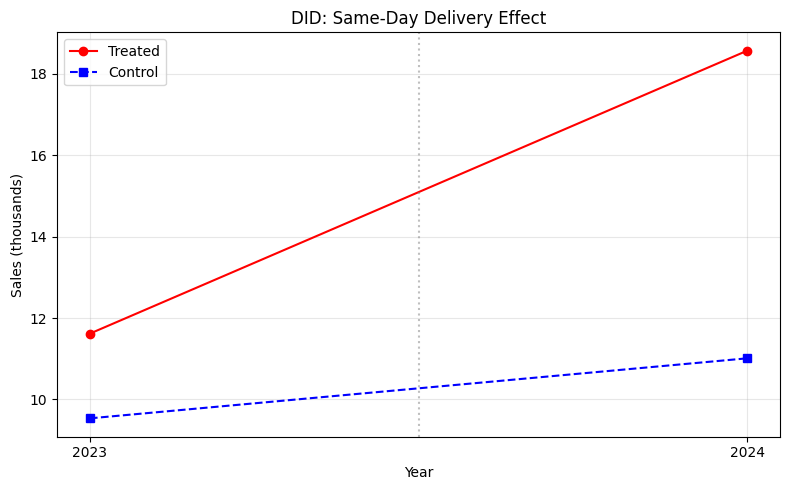

In [9]:
# Task 3: plot

# get means by year and treatment
plot_df = df_did.groupby(['year', 'treated'])['Y'].mean().reset_index()

treated = plot_df[plot_df['treated'] == 1]
control = plot_df[plot_df['treated'] == 0]

plt.figure(figsize=(8, 5))
plt.plot(treated['year'], treated['Y'], 'ro-', label='Treated')
plt.plot(control['year'], control['Y'], 'bs--', label='Control')
plt.axvline(x=2023.5, color='gray', linestyle=':', alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Sales (thousands)')
plt.title('DID: Same-Day Delivery Effect')
plt.legend()
plt.xticks([2023, 2024])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Task 4: Interpretation**

The plot shows both groups increasing from 2023 to 2024, but the treated group increases more. The gap between the lines gets bigger in 2024, which is the DID effect.

For parallel trends - if we had more pre-treatment years like 2020-2023, a violation would show up as the two lines having different slopes before treatment. Like if treated stores were already growing faster before 2024, the lines would be diverging in the pre-period. Here we only have one pre year so we can't really check this, we just have to assume the trends were parallel.